# 3 · Causal attention from scratch

This notebook stops exactly at [Attention and language · Part II](https://nipunbatra.github.io/attention/attention.html): **one** causal self-attention head, Q/K/V projections, scaled scores, causal mask, row-wise softmax, weighted values, output projection, residual addition, then a ReLU prediction MLP.

```text
token + position rows X
  ├─→ Q and K → scaled matches → causal mask → row-wise weights A
  └─→ V ────────────────────────────────→ weighted messages A·V
message → W_O → contextual update;  X + update → hidden MLP → logits
```

There is no `nn.MultiheadAttention`, fused attention call, LayerNorm, multi-head split, stacked block, or pretrained embedding. A learned position lookup and AdamW are named practical ingredients used to make the experiment trainable.


In [1]:
from pathlib import Path
import json, math, os, sys, time

HERE = Path.cwd()
if not (HERE / "wordlm.py").exists():
    matches = list(Path.cwd().rglob("word-level-next-token/wordlm.py"))
    if not matches:
        raise FileNotFoundError("Run this notebook from its word-level-next-token directory.")
    HERE = matches[0].parent
sys.path.insert(0, str(HERE))

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from wordlm import *

SEED = 11
seed_everything(SEED)
DEVICE = resolve_device(os.getenv("WORDLM_DEVICE", "auto"))
plt.style.use("seaborn-v0_8-whitegrid")
print(f"torch={torch.__version__}  device={DEVICE}")


torch=2.14.0  device=mps


## The complete route

The two maps below are our table of contents. Training sends an observed target
to the loss. Inference appends a chosen token and leaves the model parameters fixed.
Later cells highlight the same map without rearranging it.

`B` = batch size, `w` = context slots, `d` = embedding width, `h` = hidden width,
`C` = vocabulary size. In generation, `B=1`. Open Notebook 5 for the window-by-window
trace, individual model operations, optimizer step and checkpoint inference.


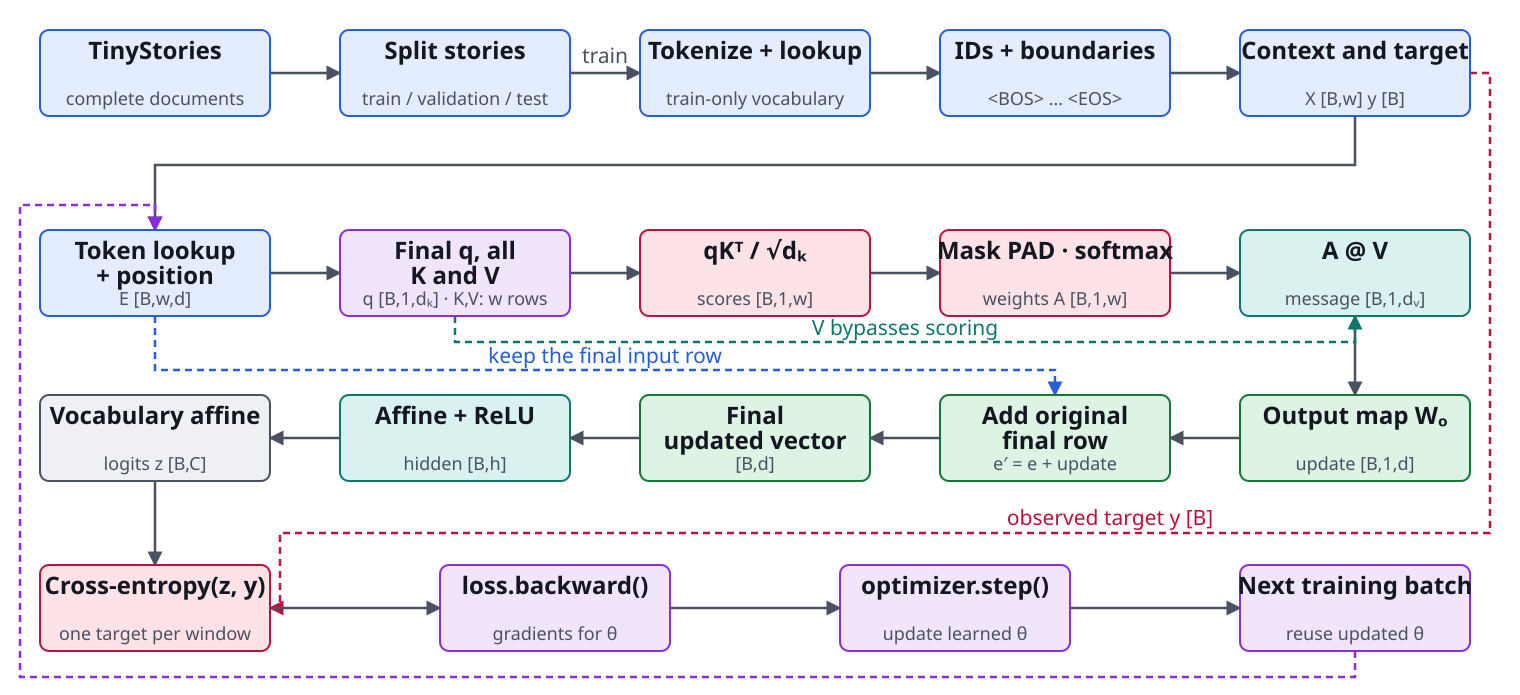

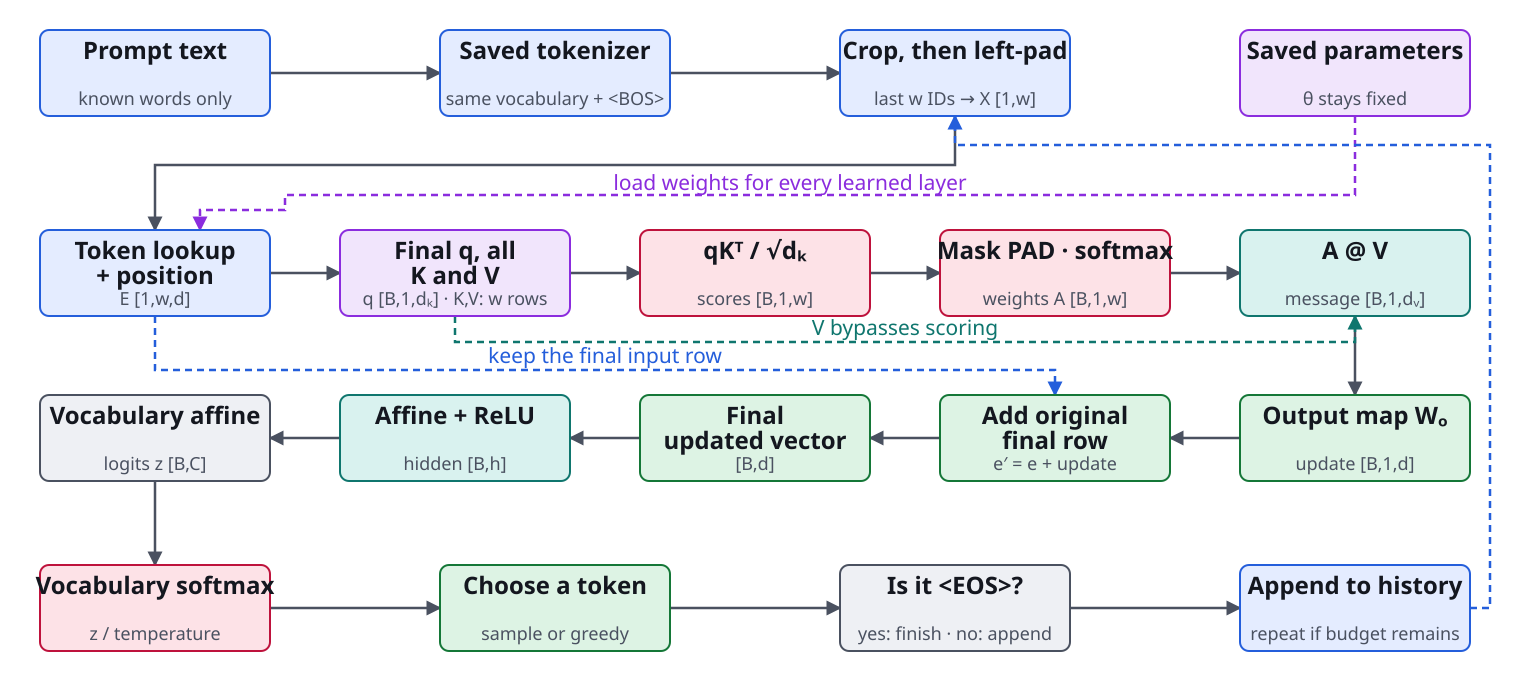

In [2]:
from pipeline_maps import show_pipeline
show_pipeline('attention', 'training')
show_pipeline('attention', 'inference')


## 1. Hand-worked tiny tensors

Let rows be token positions. Here $T=4$, $d_{model}=3$, $d_k=2$, and $d_v=2$. Queries and keys choose **where** to read; the resulting weights mix values, which carry **what** is sent.


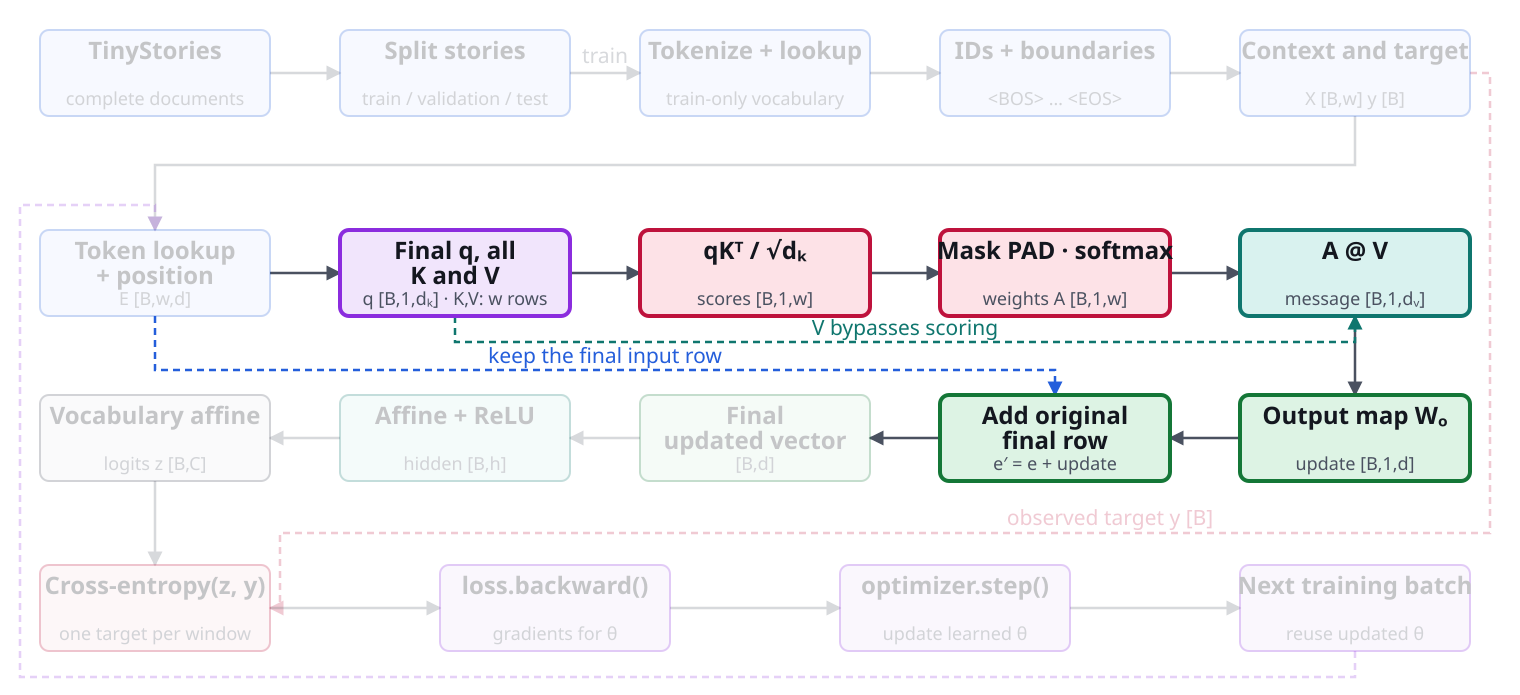

In [3]:
show_pipeline('attention', 'training', ('qkv', 'scores', 'weights', 'message', 'projection', 'residual'))


In [4]:
X_tiny = torch.tensor([
    [1.0, 0.0, 0.2],
    [0.0, 1.0, 0.1],
    [1.0, 1.0, 0.0],
    [0.5, 1.0, 0.4],
])                                                     # [T=4,d_model=3]
W_Q = torch.tensor([[1.,0.], [0.,1.], [0.5,0.5]])       # [3,2]
W_K = torch.tensor([[1.,0.], [0.,1.], [0.,0.]])         # [3,2]
W_V = torch.tensor([[1.,0.], [0.,1.], [1.,-1.]])        # [3,2]
W_O = torch.tensor([[1.,0.,0.5], [0.,1.,-0.5]])         # [2,3]

Q, K, V = X_tiny @ W_Q, X_tiny @ W_K, X_tiny @ W_V
raw_scores = Q @ K.T
scaled_scores = raw_scores / math.sqrt(Q.shape[-1])
future = torch.triu(torch.ones(4, 4, dtype=torch.bool), diagonal=1)
masked_scores = scaled_scores.masked_fill(future, float("-inf"))
A = F.softmax(masked_scores, dim=-1)
messages = A @ V
updates = messages @ W_O
contextual = X_tiny + updates

for name, tensor in [("X",X_tiny),("Q",Q),("K",K),("V",V),("scores",scaled_scores),
                     ("A",A),("messages",messages),("updates",updates),("X'",contextual)]:
    print(f"{name:9s} shape={tuple(tensor.shape)}")
print("\ncausal weights A:\n", A.round(decimals=3))
assert torch.equal(A[future], torch.zeros_like(A[future]))
assert torch.allclose(A.sum(-1), torch.ones(4))


X         shape=(4, 3)
Q         shape=(4, 2)
K         shape=(4, 2)
V         shape=(4, 2)
scores    shape=(4, 4)
A         shape=(4, 4)
messages  shape=(4, 2)
updates   shape=(4, 3)
X'        shape=(4, 3)

causal weights A:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.3300, 0.6700, 0.0000, 0.0000],
        [0.2480, 0.2480, 0.5030, 0.0000],
        [0.1520, 0.2160, 0.3550, 0.2770]])


Each row of $A$ is a probability distribution over allowed **source positions**. A zero above the diagonal means a future value contributes nothing. It is not a zero probability for a vocabulary token.

$$Q=XW_Q,\ K=XW_K,\ V=XW_V,$$
$$S=QK^\top/\sqrt{d_k},\quad A=\operatorname{softmax}_{row}(S+M),$$
$$H=AV,\quad \Delta X=HW_O,\quad X'=X+\Delta X.$$

Scaling controls score spread; subtracting a softmax maximum handles numerical overflow. They solve different problems.


## 2. Word data and positional information

Attention without position information cannot tell which identical multiset order it received. We add a learned position row of the **same width** as each word embedding. This is an architecture input, not a claim that a learned coordinate literally means “position.”


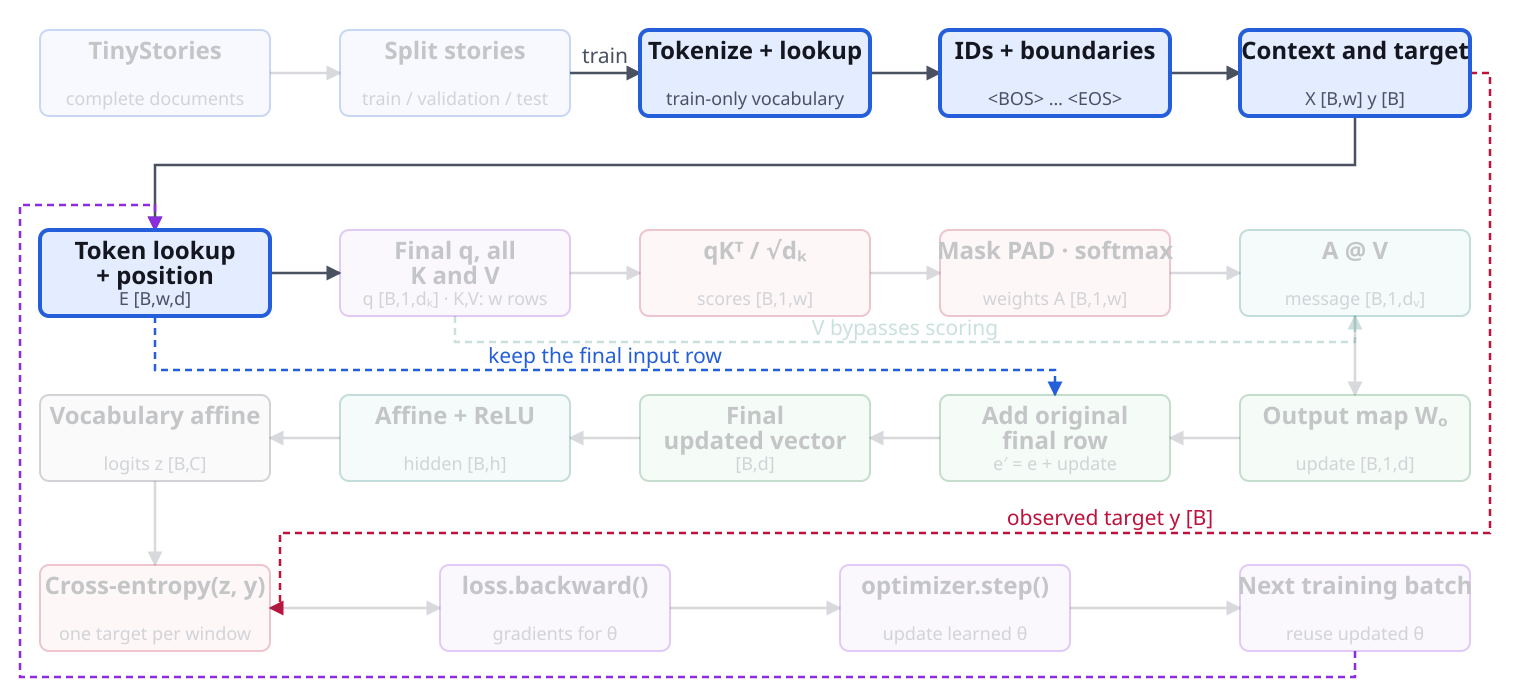

In [5]:
show_pipeline('attention', 'training', ('tokenize', 'ids', 'windows', 'embedding'))


In [6]:
PROFILE = os.getenv("WORDLM_PROFILE", "smoke")
corpus = build_corpus(HERE / "work" / "data", PROFILE)
CONTEXT_LEN = 12
windows = make_all_windows(corpus, CONTEXT_LEN)
X_train, y_train, _ = windows["train"]
X_val, y_val, _ = windows["validation"]
X_test, y_test, _ = windows["test"]
print(corpus.audit["documents"], "vocab", len(corpus.vocab.itos), "train targets", len(y_train))


{'train': 371, 'validation': 57, 'test': 52} vocab 1500 train targets 70193


## 3. The complete one-head teaching model

All intermediate tensors are returned by `forward_details` so shapes and claims can be tested. The training `forward` computes only the final causal query, which is exactly the final row of the full calculation and avoids producing unused vocabulary logits at earlier rows. The comparison still predicts exactly one target per window.


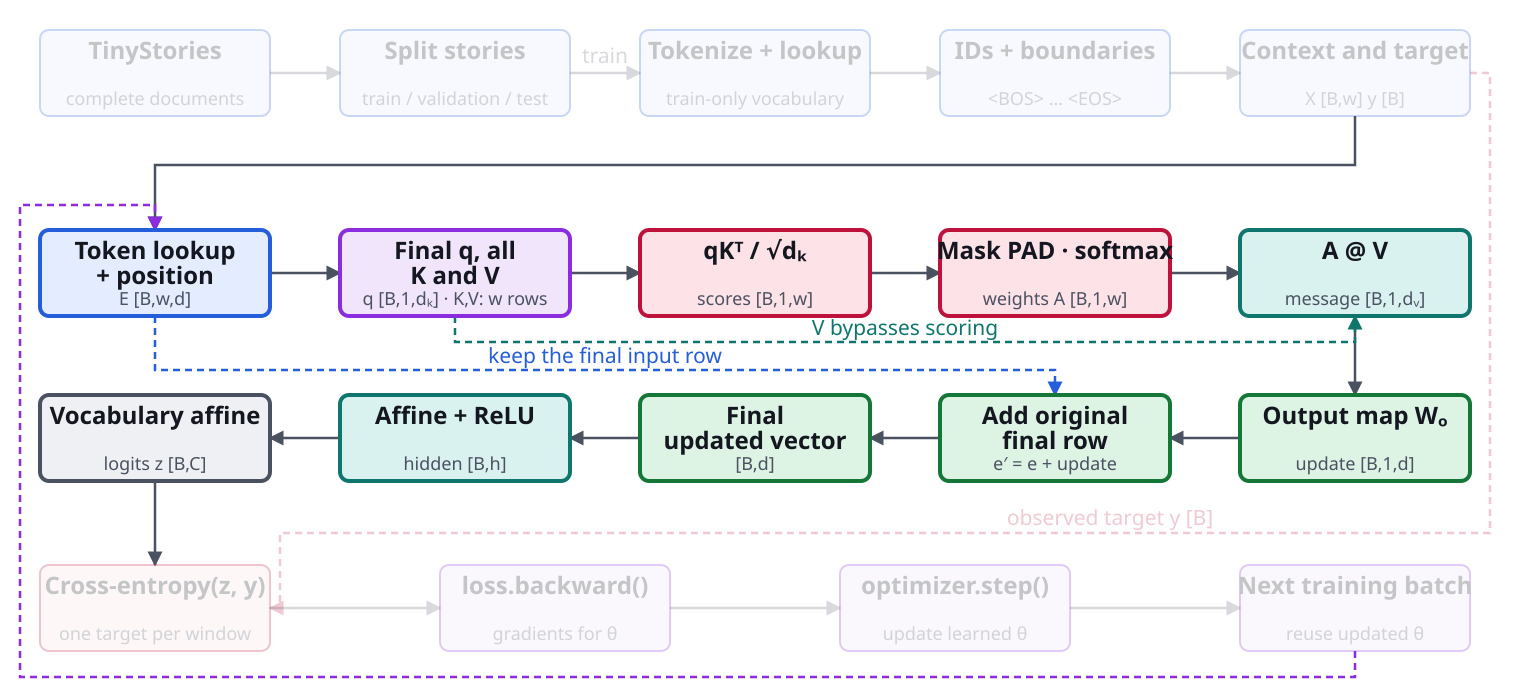

In [7]:
show_pipeline('attention', 'training', ('embedding', 'qkv', 'scores', 'weights', 'message', 'projection', 'residual', 'readout', 'hidden', 'logits'))


In [8]:
class TeachingAttentionLM(nn.Module):
    def __init__(self, vocab_size, context_len, d_model=48, d_k=48, d_v=48, hidden=160, pad_id=0):
        super().__init__()
        self.context_len, self.d_k, self.pad_id = context_len, d_k, pad_id
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.position_embedding = nn.Embedding(context_len, d_model)
        self.W_Q = nn.Linear(d_model, d_k, bias=False)
        self.W_K = nn.Linear(d_model, d_k, bias=False)
        self.W_V = nn.Linear(d_model, d_v, bias=False)
        self.W_O = nn.Linear(d_v, d_model, bias=False)
        self.hidden_layer = nn.Linear(d_model, hidden)
        self.vocab_head = nn.Linear(hidden, vocab_size)

    def forward_details(self, ids):
        B, T = ids.shape
        positions = torch.arange(T, device=ids.device)
        X = self.token_embedding(ids) + self.position_embedding(positions)[None, :, :]
        Q, K, V = self.W_Q(X), self.W_K(X), self.W_V(X)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        future = torch.triu(torch.ones(T, T, dtype=torch.bool, device=ids.device), diagonal=1)
        real = ids.ne(self.pad_id)
        padded_key_for_real_query = (~real[:, None, :]) & real[:, :, None]
        attention_mask = future[None, :, :] | padded_key_for_real_query
        masked_scores = scores.masked_fill(attention_mask, float("-inf"))
        weights = F.softmax(masked_scores, dim=-1)
        messages = weights @ V
        updates = self.W_O(messages)
        contextual = X + updates
        hidden = F.relu(self.hidden_layer(contextual))
        logits_all = self.vocab_head(hidden)
        return dict(X=X,Q=Q,K=K,V=V,scores=scores,masked_scores=masked_scores,
                    weights=weights,messages=messages,updates=updates,contextual=contextual,
                    hidden=hidden,logits_all=logits_all,logits=logits_all[:,-1,:])

    def forward(self, ids):
        _, T = ids.shape
        positions = torch.arange(T, device=ids.device)
        X = self.token_embedding(ids) + self.position_embedding(positions)[None, :, :]
        q_last, K, V = self.W_Q(X[:, -1:, :]), self.W_K(X), self.W_V(X)
        scores_last = q_last @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        scores_last = scores_last.masked_fill(ids.eq(self.pad_id)[:, None, :], float("-inf"))
        message_last = F.softmax(scores_last, dim=-1) @ V
        contextual_last = X[:, -1, :] + self.W_O(message_last).squeeze(1)
        return self.vocab_head(F.relu(self.hidden_layer(contextual_last)))


In [9]:
seed_everything(SEED)
model = TeachingAttentionLM(len(corpus.vocab.itos), CONTEXT_LEN, pad_id=corpus.vocab.pad_id)
details = model.forward_details(X_train[:3])
for name in ["X","Q","K","V","scores","weights","messages","updates","contextual","hidden","logits"]:
    print(f"{name:11s} {tuple(details[name].shape)}")
assert torch.allclose(model(X_train[:3]), details["logits"], atol=1e-6)


X           (3, 12, 48)
Q           (3, 12, 48)
K           (3, 12, 48)
V           (3, 12, 48)
scores      (3, 12, 12)
weights     (3, 12, 12)
messages    (3, 12, 48)
updates     (3, 12, 48)
contextual  (3, 12, 48)
hidden      (3, 12, 160)
logits      (3, 1500)


## 4. Mechanical checks before interpretation

A model that produces a pretty heatmap can still be wrong. We test the mask, normalization axis, causality, finite gradients, and ability to overfit 16 targets.


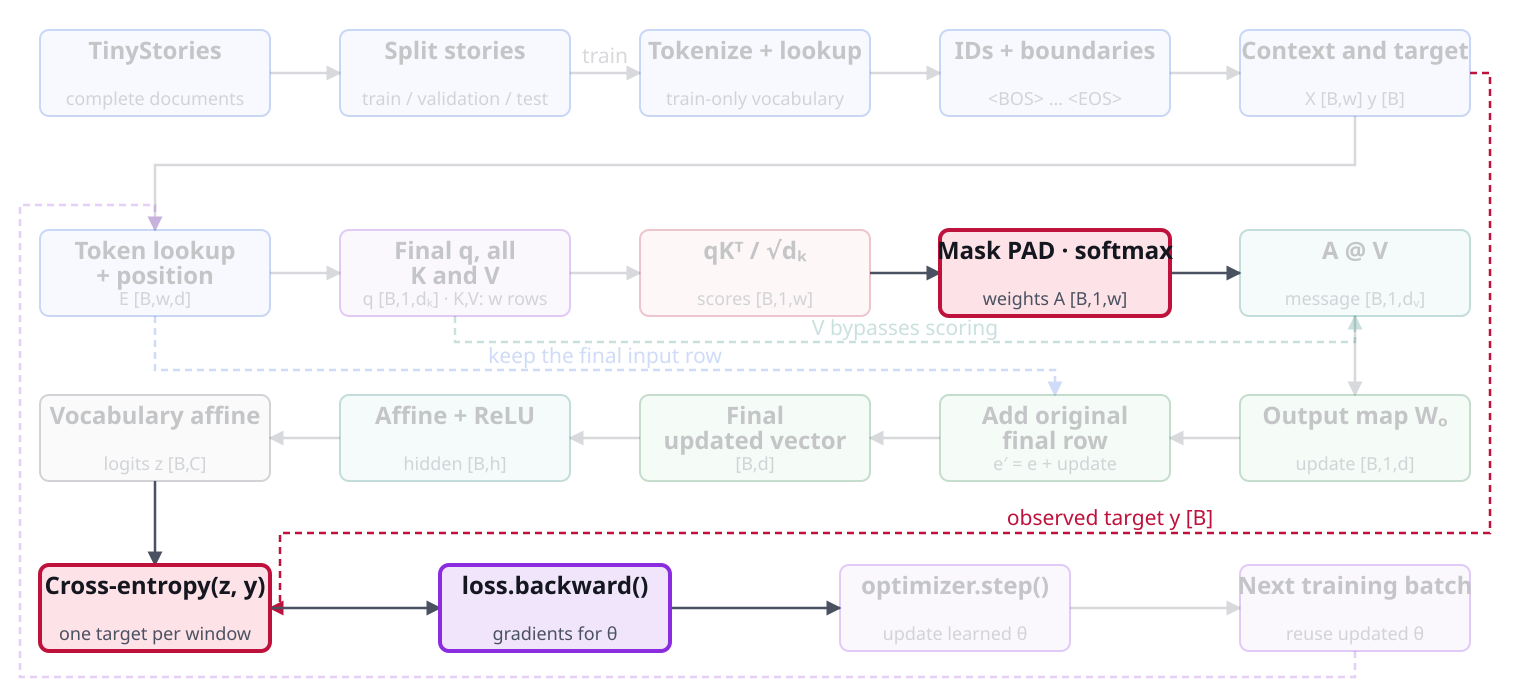

In [10]:
show_pipeline('attention', 'training', ('weights', 'loss', 'backward'))


In [11]:
checks = attention_invariants(model, X_train[:2])
print(checks)
assert checks["max_future_weight"] == 0.0
assert checks["max_row_sum_error"] < 1e-6
assert checks["max_earlier_representation_change_after_future_edit"] < 1e-6

model.zero_grad(set_to_none=True)
loss = F.cross_entropy(model(X_train[:8]), y_train[:8])
loss.backward()
assert all(p.grad is None or torch.isfinite(p.grad).all() for p in model.parameters())
print("finite loss and gradients:", float(loss))


{'max_future_weight': 0.0, 'max_row_sum_error': 1.1920928955078125e-07, 'max_earlier_representation_change_after_future_edit': 0.0, 'all_finite': True}
finite loss and gradients: 7.618092060089111


/var/folders/1x/wmgn24mn1bbd2vgbqlk98tbc0000gn/T/ipykernel_22223/2336937288.py:11: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:821.)
  print("finite loss and gradients:", float(loss))


In [12]:
seed_everything(31)
debug_model = TeachingAttentionLM(len(corpus.vocab.itos), CONTEXT_LEN, d_model=32, d_k=32, d_v=32, hidden=96, pad_id=corpus.vocab.pad_id)
before, after = tiny_batch_overfit(debug_model, X_train, y_train, device=DEVICE, steps=220)
print(f"tiny-batch loss: {before:.3f} → {after:.5f}")
assert after < min(0.15, before / 10)


tiny-batch loss: 7.545 → 0.00000


## 5. Actually train the one-head model

This smoke run uses one target per window—the same loss unit as the MLP. The larger, multi-seed, matched-context comparison is reserved for Notebook 4.


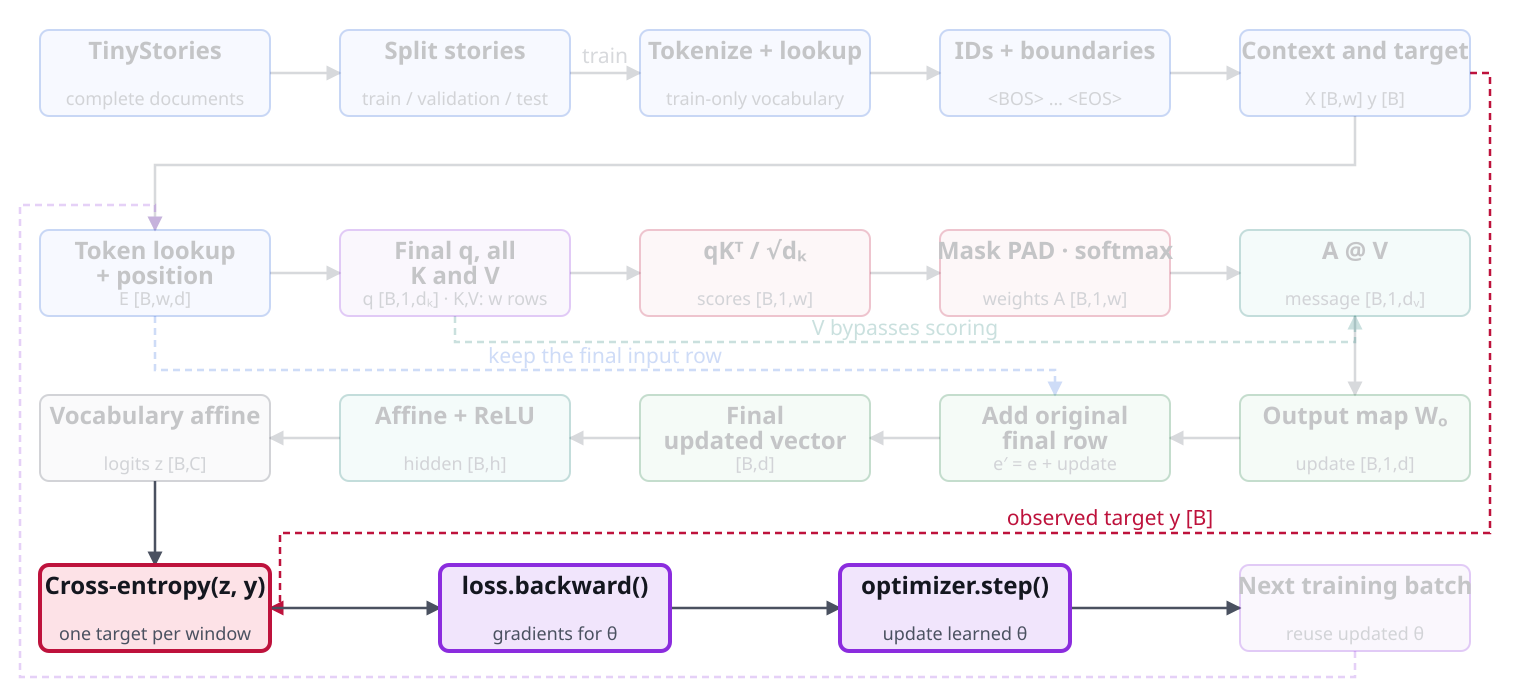

In [13]:
show_pipeline('attention', 'training', ('loss', 'backward', 'optimizer'))


In [14]:
seed_everything(SEED)
model = TeachingAttentionLM(len(corpus.vocab.itos), CONTEXT_LEN, pad_id=corpus.vocab.pad_id)
config = TrainConfig(steps=300, batch_size=256, learning_rate=3e-3, weight_decay=1e-4,
                     seed=SEED, eval_every=50, eval_examples=20_000)
result, _ = train_model(model, X_train, y_train, X_val, y_val, config, device=DEVICE)
test_loss = evaluate_loss(model, X_test, y_test, device=DEVICE)
print(f"validation CE={result['validation_loss']:.3f}, PPL={math.exp(result['validation_loss']):.2f}")
print(f"test CE={test_loss:.3f}, PPL={math.exp(test_loss):.2f} (after settings were fixed)")
print(f"parameters={count_parameters(model):,}, tokens seen={result['tokens_seen']:,}, runtime={result['runtime_seconds']:.1f}s")


validation CE=4.069, PPL=58.48
test CE=4.172, PPL=64.87 (after settings were fixed)
parameters=331,132, tokens seen=76,800, runtime=2.4s


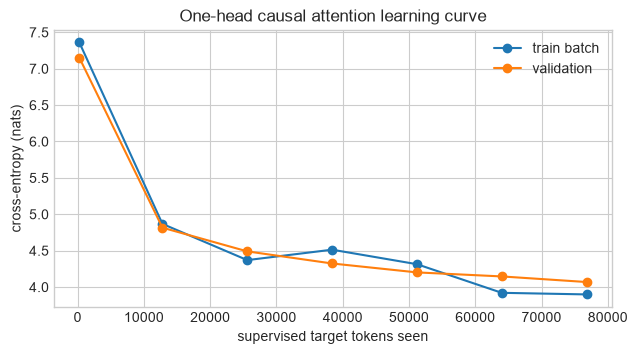

In [15]:
trace = result["trace"]
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot([p["tokens_seen"] for p in trace], [p["train_batch_loss"] for p in trace], "o-", label="train batch")
ax.plot([p["tokens_seen"] for p in trace], [p["validation_loss"] for p in trace], "o-", label="validation")
ax.set(xlabel="supervised target tokens seen", ylabel="cross-entropy (nats)", title="One-head causal attention learning curve")
ax.legend(); plt.show()


### The inference loop on the same map

Reuse the saved tokenizer and vocabulary. Crop long history to the last `w`
tokens, left-pad a shorter prefix, predict, choose a token and append it.
Stop on `<EOS>` or the token limit. This implementation recomputes the window;
it does not use a KV cache. No target, backward pass or optimizer step is involved.


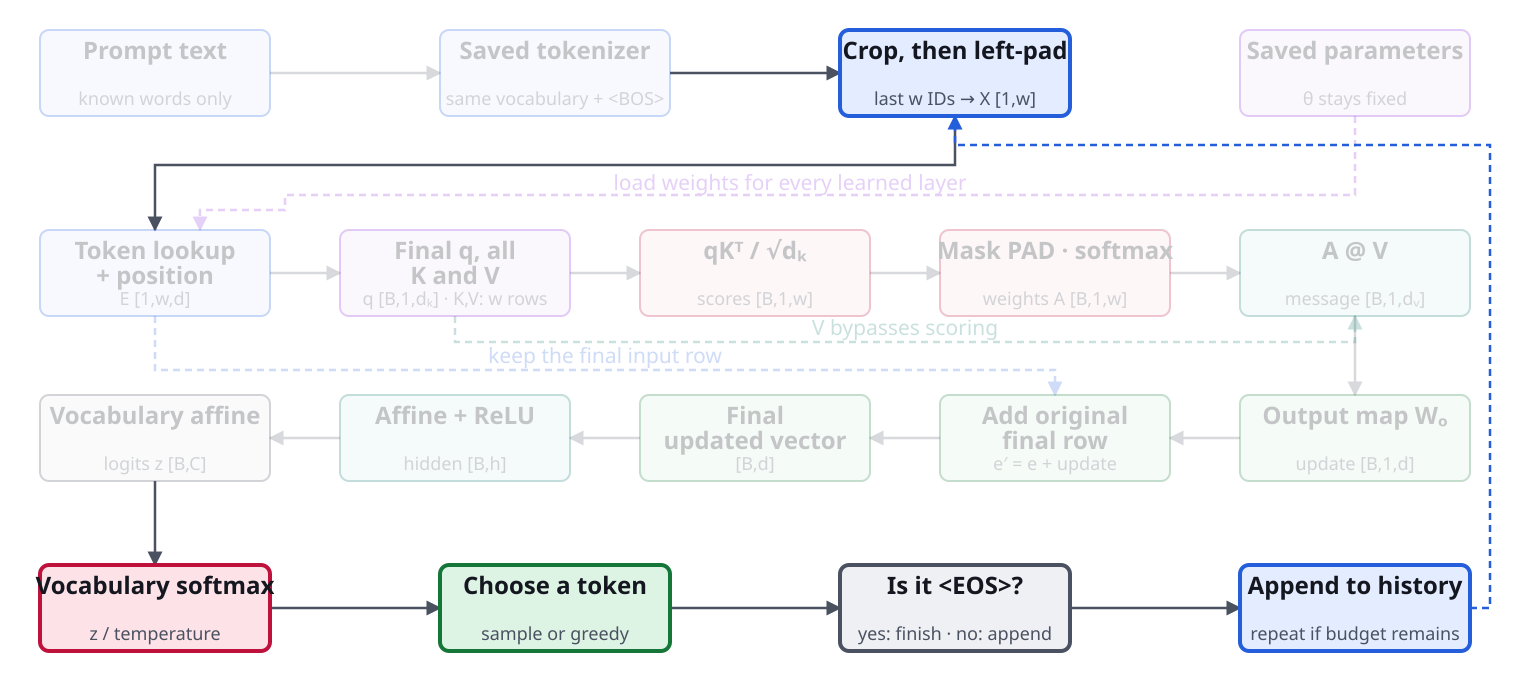

In [16]:
show_pipeline('attention', 'inference', ('windows','probabilities','choose','append','stop'))


In [17]:
for temperature in [0.8, 1.0]:
    print(f"T={temperature:.1f}:", generate_text(
        model, corpus.vocab, "once upon a time", context_len=CONTEXT_LEN,
        max_new_tokens=45, temperature=temperature, seed=8, device=DEVICE,
    ))


T=0.8: once upon a time, there was a little girl named timmy was a fairy who lived for her mom opened her friends. he went to the milk. it was playing. he said, but they continued,"mom smiled and said,"i'm
T=1.0: once upon a time, there was a cloth was friends and said babies as who lived for her mom opened her picture in him.


**Scope.** This model demonstrates learned causal routing and next-token training. It is not a complete Transformer: no multiple heads, block FFN, LayerNorm, stacked blocks, or pretrained representation has been silently added. Notebook 4 asks what the measured model—not an imagined semantic-axis story—actually learned.
